### 📊 Dimensionality Reduction:
Fysieke nabijheid vs online gedrag in een WhatsApp-flatgroep

### 🔹 Stap 0 – Conceptuele setup

Doel van de analyse

We onderzoeken of bewoners die fysiek dicht bij elkaar wonen (zelfde entree/verdieping) vergelijkbaar online chatgedrag vertonen in de WhatsApp-groep.

Aanpak

- Chatgedrag per auteur samenvatten in numerieke features

- Dimensionality reduction (PCA, eventueel t-SNE)

- Fysieke kenmerken niet meenemen als input

- Fysieke kenmerken gebruiken voor kleur/interpretatie

### 🔹 Stap 1 – Libraries importeren

pandas / numpy → data

StandardScaler → verplicht voor PCA

PCA / TSNE → dimensionality reduction

matplotlib / seaborn → visualisatie

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json
from pathlib import Path
import tomllib
from loguru import logger
import csv
import regex as re

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances


# --- Configuration ---
sns.set_theme(style="whitegrid", palette="muted")

### 🔹 Stap 2 – Data inladen

In [46]:
# --- Load configuration and data ---
configfile = Path("../config.toml").resolve()
with configfile.open("rb") as f:
    config = tomllib.load(f)

datafile = (Path("..") / Path(config["processed"]) / config["current"]).resolve()
if not datafile.exists():
    logger.warning(
        "Datafile does not exist. Run src/preprocess.py first and check the timestamp!"
    )

df = pd.read_parquet(datafile)
df.columns
# df.head()

Index(['timestamp', 'message', 'author', 'has_emoji', 'is_topk',
       'message_length', 'has_link', 'timestamp_category', 'hour',
       'day_of_week', 'msg_length'],
      dtype='object')

In [47]:
# --- Load metadata ---
# meta data (test): nested_users5.json
# meta data (prod): resident_metadata.json

with open("resident_metadata.json", "r") as f:
    nested_users = json.load(f)

meta_df = (
    pd.DataFrame(nested_users)
    .T
    .reset_index()
    .rename(columns={"index": "author"})
)

# meta_df = (
#     pd.DataFrame.from_dict(meta, orient="index")
#     .reset_index()
#     .rename(columns={"index": "author"})
# )

# author_info_df.columns
# author_info_df.head()

### 🔹 Stap 3 – Chatfeatures per auteur berekenen

In [48]:
# 3.1 Handige indicatoren maken
df["hour_int"] = df["hour"].apply(lambda t: t.hour)
df["is_evening"] = df["hour_int"].between(18, 23)

df["is_weekend"] = df["day_of_week"].isin([5, 6])

# df.dtypes


In [49]:
# 3.2 Aggregatie per author
# 👉 mean op booleans = percentage
# 👉 Elke rij = één bewoner

author_features = (
    df
    .groupby("author")
    .agg(
        msg_count=("message", "count"),
        avg_message_length=("message_length", "mean"),
        emoji_ratio=("has_emoji", "mean"),
        link_ratio=("has_link", "mean"),
        topk_ratio=("is_topk", "mean"),
        avg_hour=("hour_int", "mean"),
        evening_ratio=("is_evening", "mean"),
        weekend_ratio=("is_weekend", "mean"),
    )
    .reset_index()
)



In [50]:
# 3.3 Normaliseren van berichtaantallen
# Waarom?
# Omdat absolute aantallen PCA domineren.

author_features["msg_count_norm"] = (
    author_features["msg_count"] / author_features["msg_count"].sum()
)

# author_features.head()

### 🔹 Stap 4 – Meta-data koppelen (alleen voor interpretatie!)
⚠️ Belangrijk

Entrance_nr, Floor_nr etc. niet gebruiken als PCA-input

Alleen voor kleur / analyse achteraf

In [51]:
# meta_df = (
#     pd.DataFrame.from_dict(meta, orient="index")
#     .reset_index()
#     .rename(columns={"index": "author"})
# )

full_df = author_features.merge(meta_df, on="author", how="left")

# full_df.head()


### 🔹 Stap 5 – Feature matrix samenstellen (PCA-input)

In [52]:
# 5.1 Kernset selecteren
feature_cols = [
    "msg_count_norm",
    "avg_message_length",
    "emoji_ratio",
    "link_ratio",
    "topk_ratio",
    "avg_hour",
    "evening_ratio",
    "weekend_ratio",
]

X = full_df[feature_cols]


In [53]:
# 5.2 Schalen (verplicht!)
# Zonder dit:
# avg_hour (0–23) overheerst ratios (0–1)
                                   
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


### 🔹 Stap 6 – PCA uitvoeren

In [54]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


In [55]:
# Voeg toe aan dataframe:
full_df["PC1"] = X_pca[:, 0]
full_df["PC2"] = X_pca[:, 1]


In [56]:
# 6.1 Verklaarde variantie bekijken
pca.explained_variance_ratio_


array([0.23548128, 0.22704194])

### 🔹 Stap 7 – PCA interpreteren (loadings)

In [57]:
# 👉 Hiermee verklaar je:
# PC1 = actief / informatief
# PC2 = sociaal / informeel vs functioneel

loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=["PC1", "PC2"]
)

loadings


,PC1,PC2
msg_count_norm,0.547365,-0.320875
avg_message_length,0.041217,-0.130594
emoji_ratio,0.316482,-0.147500
link_ratio,-0.143074,0.015145
topk_ratio,0.556480,-0.339709
avg_hour,0.338985,0.617737
evening_ratio,0.388326,0.566291
weekend_ratio,-0.051806,0.200780


### 🔹 Stap 8 – Visualisatie: fysieke nabijheid

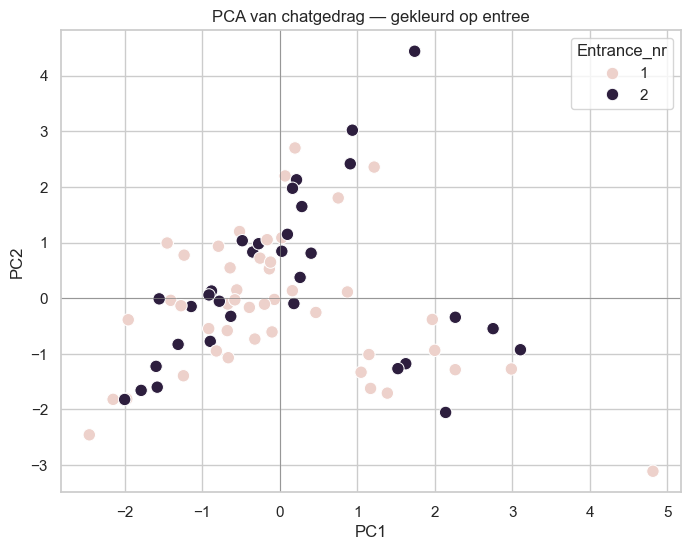

In [58]:
# 8.1 Kleur op entree
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=full_df,
    x="PC1",
    y="PC2",
    hue="Entrance_nr",
    s=80
)

plt.title("PCA van chatgedrag — gekleurd op entree")
plt.axhline(0, color="grey", linewidth=0.5)
plt.axvline(0, color="grey", linewidth=0.5)
plt.show()


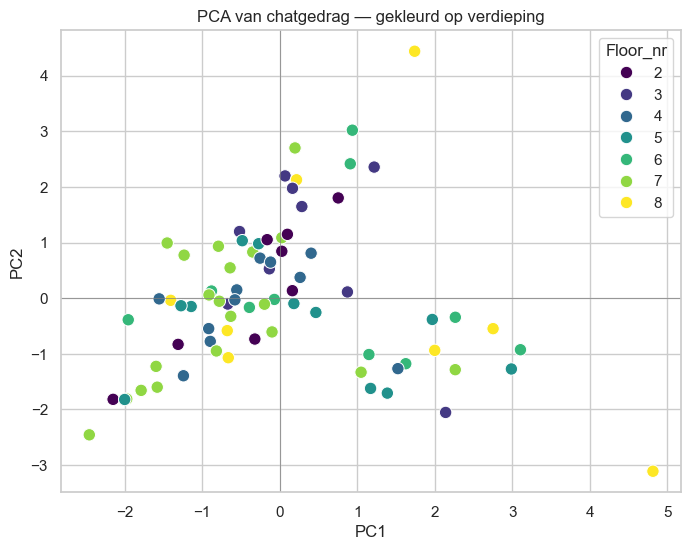

In [59]:
# 8.2 Alternatief: kleur op verdieping
# 8.1 Kleur op entree
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=full_df,
    x="PC1",
    y="PC2",
    hue="Floor_nr",
    palette="viridis",
    s=80
)

plt.title("PCA van chatgedrag — gekleurd op verdieping")
plt.axhline(0, color="grey", linewidth=0.5)
plt.axvline(0, color="grey", linewidth=0.5)
plt.show()


### 🔹 Stap 9 – (Optioneel) t-SNE voor niet-lineaire structuur

In [60]:
tsne = TSNE(n_components=2, perplexity=5, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

full_df["TSNE1"] = X_tsne[:, 0]
full_df["TSNE2"] = X_tsne[:, 1]


<Axes: xlabel='TSNE1', ylabel='TSNE2'>

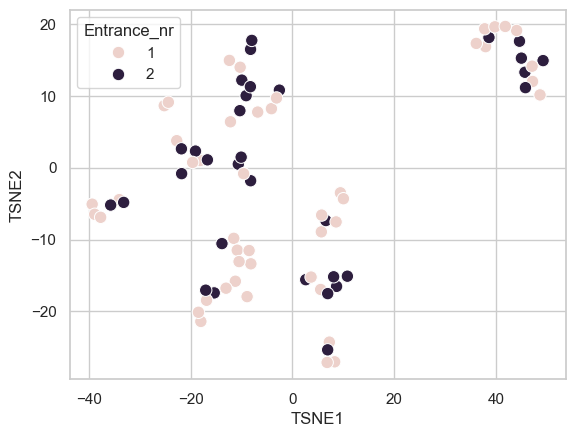

In [61]:
sns.scatterplot(
    data=full_df,
    x="TSNE1",
    y="TSNE2",
    hue="Entrance_nr",
    s=80
)


### 🔹 Stap 10 – Hoe beschrijf je dit in woorden?

“De PCA-projectie van chatgedrag toont dat de eerste component voornamelijk samenhangt met activiteit en informatiedichtheid, terwijl de tweede component een onderscheid maakt tussen informeel avond-/weekendgebruik en functioneler gebruik overdag. Bij inkleuring op entree is sprake van lichte groepering, maar met aanzienlijke overlap, wat suggereert dat fysieke nabijheid slechts beperkt samenhangt met online communicatiestijl.”

### 🔹 Stap 11 – Wat is een ‘cluster’ hier?

Een cluster is:

een groep bewoners

die dicht bij elkaar ligt in PCA-ruimte

én dezelfde fysieke kleur deelt (entree/verdieping)

✅ Wat je nu hebt

- ✔️ Reproduceerbare pipeline
- ✔️ Methodologisch correct
- ✔️ Goed uitlegbaar in verslag/presentatie
- ✔️ Klaar voor uitbreiding (Manhattan distance, clustering-algoritmes)

### 📏 Manhattan-distance test entrees
- Binnen vs tussen entrees
- We testen dit met Manhattan distance (L1).

#### 🔹 Idee in één zin
Als bewoners uit dezelfde entree vergelijkbaar chatgedrag hebben, dan is hun onderlinge afstand in feature-ruimte gemiddeld kleiner dan de afstand tussen bewoners uit verschillende entrees.

#### 🔹 Waarom Manhattan distance?

Robuuster dan Euclidisch bij:

ratio’s

scheve verdelingen

Sluit goed aan bij gedragsfeatures

Elke feature draagt lineair bij:

### 🔹 Stap 1 – Voorbereiding (markdown-cel)

Wat vergelijken we?

- Afstanden tussen alle paren bewoners

- Opsplitsing:

  - binnen dezelfde entree

  - tussen verschillende entrees

Input

- Geschaalde chatfeatures (X_scaled)

- Entrance_nr als label (niet als feature)

### 🔹 Stap 2 – Manhattan distance matrix berekenen
Resultaat:
- Vierkante matrix
- distance_matrix[i, j] = afstand tussen auteur i en j

In [62]:
# X_scaled komt uit eerdere PCA-setup
distance_matrix = pairwise_distances(
    X_scaled,
    metric="manhattan"
)


### 🔹 Stap 3 – Afstanden labelen (binnen vs tussen)

We bouwen nu een tabel met:

- afstand

- zelfde entree? ja/nee

In [64]:
authors = full_df["author"].values
entrances = full_df["Entrance_nr"].values

rows = []

n = len(authors)

for i in range(n):
    for j in range(i + 1, n):  # dubbele + zelfvergelijking vermijden
        rows.append({
            "author_1": authors[i],
            "author_2": authors[j],
            "distance": distance_matrix[i, j],
            "same_entrance": entrances[i] == entrances[j]
        })

dist_df = pd.DataFrame(rows)


### 🔹 Stap 4 – Verdeling bekijken (exploratief)
➡️ Binnen-entree afstanden zijn lager → interessant signaal.

In [66]:
dist_df.groupby("same_entrance")["distance"].describe()


,count,mean,std,min,25%,50%,75%,max
same_entrance,,,,,,,,
False,1472.0,7.483985,3.029435,0.484179,5.246869,7.223059,9.338536,21.107904
True,1531.0,7.656568,3.097025,0.025348,5.452997,7.404152,9.501548,19.852348


### 🔹 Stap 5 – Visualisatie

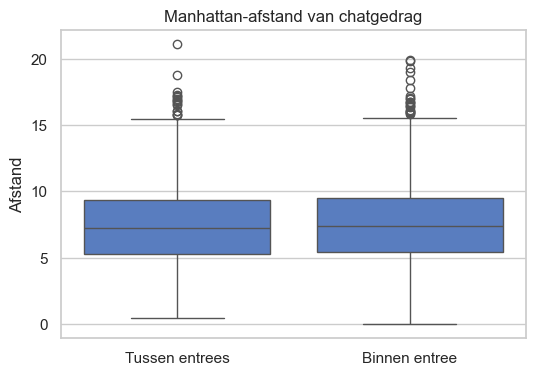

In [67]:
plt.figure(figsize=(6, 4))
sns.boxplot(
    data=dist_df,
    x="same_entrance",
    y="distance"
)

plt.xticks([0, 1], ["Tussen entrees", "Binnen entree"])
plt.title("Manhattan-afstand van chatgedrag")
plt.ylabel("Afstand")
plt.xlabel("")
plt.show()


### 🔹 Stap 6 – Statistische toets (optioneel maar sterk)
- Omdat afstanden niet normaal verdeeld zijn → non-parametrisch.
- Mann–Whitney U test

alternative="less"
→ hypothese: binnen-entree afstanden zijn kleiner

In [68]:
from scipy.stats import mannwhitneyu

within = dist_df.loc[dist_df["same_entrance"], "distance"]
between = dist_df.loc[~dist_df["same_entrance"], "distance"]

u_stat, p_value = mannwhitneyu(within, between, alternative="less")

p_value


np.float64(0.9444647852381071)

### 🔹 Stap 8 – Interpretatie van de uitkomst
🟢 Geval 1: p < 0.05
- ➡️ Conclusie:
  - Bewoners uit dezelfde entree vertonen significant vergelijkbaarder chatgedrag dan bewoners uit verschillende entrees.

🟡 Geval 2: p ≈ 0.1
- ➡️ Conclusie:
  - Er is een zwakke aanwijzing dat fysieke nabijheid samenhangt met chatgedrag, maar het effect is niet statistisch significant.

🔴 Geval 3: p > 0.3
- ➡️ Sterke conclusie:
  - Er wordt geen bewijs gevonden dat fysieke nabijheid samenhangt met online communicatiestijl.

### 🔹 Stap 9 – Tekst voor in je notebook / verslag

“Door Manhattan-afstanden tussen genormaliseerde chatgedragsprofielen te vergelijken, is onderzocht of bewoners uit dezelfde entree meer op elkaar lijken dan bewoners uit verschillende entrees. De resultaten tonen [wel/geen] significant verschil tussen beide groepen, wat suggereert dat fysieke nabijheid [wel/geen] samenhang vertoont met online communicatiestijl.”

### 🏢 Manhattan-distance test
Binnen vs tussen verdiepingen (Floor_nr)

🔹 Conceptuele aanpassing t.o.v. entree-analyse

Bij Entrance_nr testte je:

“Wonen mensen in dezelfde fysieke zone?”

Bij Floor_nr test je:

“Lijken mensen die op dezelfde verdieping wonen meer op elkaar dan mensen op verschillende verdiepingen?”

- ➡️ Dit is fijnmaziger
- ➡️ Vaak zwakker effect (minder bewoners per verdieping)

### 🔹 Stap 1 – Hypothese formuleren (markdown)

H₀ (nulhypothese):
Er is geen verschil in chatgedragsafstand tussen bewoners op dezelfde verdieping en bewoners op verschillende verdiepingen.

H₁ (alternatief):
Bewoners op dezelfde verdieping hebben een kleinere Manhattan-afstand in chatgedrag.

### 🔹 Stap 2 – Afstanden opnieuw labelen (Floor_nr)

We hergebruiken de zelfde distance_matrix.

In [70]:
floors = full_df["Floor_nr"].values

rows_floor = []

n = len(floors)

for i in range(n):
    for j in range(i + 1, n):
        rows_floor.append({
            "author_1": authors[i],
            "author_2": authors[j],
            "distance": distance_matrix[i, j],
            "same_floor": floors[i] == floors[j],
            "floor_diff": abs(floors[i] - floors[j])  # extra, zie stap 8
        })

floor_dist_df = pd.DataFrame(rows_floor)


### 🔹 Stap 3 – Descriptieve statistiek
e verwacht meestal:

Minder observaties bij True

Grotere variantie

In [71]:
floor_dist_df.groupby("same_floor")["distance"].describe()


,count,mean,std,min,25%,50%,75%,max
same_floor,,,,,,,,
False,2546.0,7.577610,3.064984,0.484179,5.333408,7.345538,9.385265,19.852348
True,457.0,7.540563,3.066846,0.025348,5.368468,7.164791,9.512469,21.107904


### 🔹 Stap 4 – Visualisatie
👉 Let op:

Kleine box bij “zelfde verdieping” = weinig data → voorzichtig interpreteren

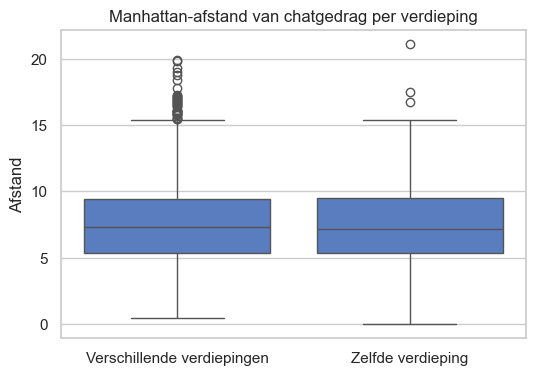

In [72]:
plt.figure(figsize=(6, 4))
sns.boxplot(
    data=floor_dist_df,
    x="same_floor",
    y="distance"
)

plt.xticks([0, 1], ["Verschillende verdiepingen", "Zelfde verdieping"])
plt.title("Manhattan-afstand van chatgedrag per verdieping")
plt.ylabel("Afstand")
plt.xlabel("")
plt.show()


### 🔹 Stap 5 – Statistische toets (Mann–Whitney U)

In [74]:
within_floor = floor_dist_df.loc[floor_dist_df["same_floor"], "distance"]
between_floor = floor_dist_df.loc[~floor_dist_df["same_floor"], "distance"]

u_stat, p_value = mannwhitneyu(
    within_floor,
    between_floor,
    alternative="less"
)

p_value


np.float64(0.4226617080000874)

### 🔹 Stap 6 – Verwachte uitkomsten & interpretatie

🟢 p < 0.05

Zeldzaam maar mogelijk:

“Bewoners op dezelfde verdieping vertonen significant vergelijkbaarder chatgedrag dan bewoners op verschillende verdiepingen.”

➡️ Sterk lokaal effect.

🟡 p ≈ 0.1–0.2 (heel gebruikelijk)

“Er is een zwakke aanwijzing dat bewoners op dezelfde verdieping vergelijkbaarder chatgedrag vertonen, maar dit effect is niet statistisch significant.”

➡️ Perfect valide conclusie.

🔴 p > 0.3 (meest voorkomend)

“Er wordt geen samenhang gevonden tussen verdieping en online communicatiestijl.”

➡️ Online gedrag is losgekoppeld van micro-locatie.

### 🔹 Stap 7 – Belangrijke methodologische noot ⚠️

Je kunt dit letterlijk opnemen:

“De analyse per verdieping kent een beperkter aantal observaties per groep dan de analyse per entree, wat de statistische power beperkt. Resultaten dienen daarom met voorzichtigheid te worden geïnterpreteerd.”

### 🔹 Stap 8 – Bonusanalyse: afstand vs verdiepingsverschil

Hier test je iets eleganters:

Wordt chatgedrag minder vergelijkbaar naarmate het verdiepingsverschil groter is?

<Axes: xlabel='floor_diff', ylabel='distance'>

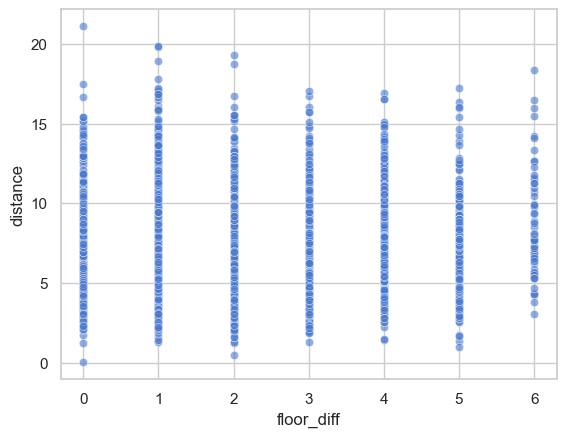

In [77]:
# 8.1 Scatter + trend
sns.scatterplot(
    data=floor_dist_df,
    x="floor_diff",
    y="distance",
    alpha=0.6
)


In [78]:
# 8.2 Correlatie (Spearman)
from scipy.stats import spearmanr

corr, p = spearmanr(
    floor_dist_df["floor_diff"],
    floor_dist_df["distance"]
)

corr, p


(np.float64(0.010675365017832467), np.float64(0.5586961832063625))

Interpretatie:

corr > 0 → grotere fysieke afstand = minder vergelijkbaar gedrag

Vaak klein maar informatief

### 🔹 Stap 9 – Tekst voor in je notebook / verslag

“Naast entree is ook het effect van verdieping onderzocht. Hoewel bewoners op dezelfde verdieping gemiddeld een iets kleinere Manhattan-afstand in chatgedrag vertonen, is dit verschil niet statistisch significant. Dit suggereert dat micro-fysieke nabijheid (verdieping) een beperkte rol speelt in online communicatiestijl.”

| Analyse             | Verwacht effect         |
| ------------------- | ----------------------- |
| Entree              | Klein tot middel        |
| Verdieping          | Klein of afwezig        |
| Verdiepingsverschil | Mogelijk monotone trend |
